# 📖 Notebook 04: 学習と推論（テキスト生成）
## — モデルを鍛え、テキストを生み出す仕組み —

### このノートで学ぶこと

| セクション | 内容 |
|-----------|------|
| 1. 損失関数 | Cross-Entropy Loss で「どれだけ間違えているか」を数値化 |
| 2. 勾配の直感 | 数値微分で「勾配とは何か」を体感 |
| 3. 解析的勾配 | Softmax + CE の美しい勾配公式 |
| 4. 学習ループ | SGD で損失を下げ続ける |
| 5. 自己回帰生成 | トークンを 1 つずつ生成するアルゴリズム |
| 6. サンプリング戦略 | Greedy / Temperature / Top-k の違い |

### 言語モデルの学習タスク：次トークン予測

```
入力:  [A, B, C, D]   ← これを与えて
正解:  [B, C, D, E]   ← これを予測する
```

1 系列から `seq_len` 個の学習サンプルが得られます（超効率的！）

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

np.random.seed(42)
np.set_printoptions(precision=4, suppress=True)
plt.rcParams.update({'font.size': 11, 'figure.dpi': 110})

# =====================================================
# 全コンポーネントの再定義（NB01〜03 のまとめ）
# =====================================================
vocab_size = 8
d_model    = 4
n_layers   = 2
num_heads  = 2
d_ff       = 8
tokens     = [2, 5, 1, 3]
idx2word   = {0:'<PAD>', 1:'A', 2:'B', 3:'C', 4:'D', 5:'E', 6:'F', 7:'G'}

def softmax(x, axis=-1):
    e = np.exp(x - x.max(axis=axis, keepdims=True))
    return e / e.sum(axis=axis, keepdims=True)

def gelu(x):
    return 0.5*x*(1+np.tanh(np.sqrt(2/np.pi)*(x+0.044715*x**3)))

def positional_encoding(seq_len, d_model):
    PE = np.zeros((seq_len, d_model))
    for pos in range(seq_len):
        for i in range(0, d_model, 2):
            a = pos / (10000**(2*i/d_model))
            PE[pos, i] = np.sin(a)
            if i+1 < d_model: PE[pos, i+1] = np.cos(a)
    return PE

def sdpa(Q, K, V):
    L, dk = Q.shape
    s = Q @ K.T / np.sqrt(dk)
    s[np.triu(np.ones((L,L),dtype=bool),k=1)] = -1e9
    return softmax(s,axis=-1) @ V

class MHA:
    def __init__(self, d_model, nh, seed=0):
        self.nh = nh; self.dk = d_model//nh
        r = np.random.default_rng(seed)
        self.WQ=[r.standard_normal((d_model,self.dk))*0.5 for _ in range(nh)]
        self.WK=[r.standard_normal((d_model,self.dk))*0.5 for _ in range(nh)]
        self.WV=[r.standard_normal((d_model,self.dk))*0.5 for _ in range(nh)]
        self.WO=r.standard_normal((d_model,d_model))*0.5
    def forward(self,X):
        return np.concatenate([sdpa(X@self.WQ[h],X@self.WK[h],X@self.WV[h])
                               for h in range(self.nh)],axis=-1)@self.WO

class LN:
    def __init__(self,d,eps=1e-6):
        self.g=np.ones(d); self.b=np.zeros(d); self.eps=eps
    def forward(self,x):
        m=x.mean(-1,keepdims=True); v=x.var(-1,keepdims=True)
        return self.g*(x-m)/np.sqrt(v+self.eps)+self.b

class FFN:
    def __init__(self,d,dff,seed=0):
        r=np.random.default_rng(seed)
        self.W1=r.standard_normal((d,dff))*0.3; self.b1=np.zeros(dff)
        self.W2=r.standard_normal((dff,d))*0.3;  self.b2=np.zeros(d)
    def forward(self,x):
        return gelu(x@self.W1+self.b1)@self.W2+self.b2

class Block:
    def __init__(self,d,nh,dff,seed=0):
        self.mha=MHA(d,nh,seed); self.ffn=FFN(d,dff,seed+1)
        self.ln1=LN(d); self.ln2=LN(d)
    def forward(self,X):
        X=self.ln1.forward(X+self.mha.forward(X))
        return self.ln2.forward(X+self.ffn.forward(X))

np.random.seed(42)
E      = np.random.randn(vocab_size, d_model)
blocks = [Block(d_model, num_heads, d_ff, seed=i*10) for i in range(n_layers)]
np.random.seed(99)
W_lm   = np.random.randn(d_model, vocab_size) * 0.3

def model_forward(token_ids_list):
    ids = np.array(token_ids_list)
    X = E[ids] + positional_encoding(len(ids), d_model)
    for blk in blocks:
        X = blk.forward(X)
    return X @ W_lm, X

logits, hidden = model_forward(tokens)
print(f"モデル初期化完了")
print(f"  logits shape: {logits.shape}")

モデル初期化完了
  logits shape: (4, 8)


---
## 1. Cross-Entropy Loss（交差エントロピー損失）

### 直感

モデルが正解トークンに **確率 1.0** を割り当てれば損失 = 0。  
確率が低いほど「驚き（surprise）」が大きく、損失が高くなります。

$$\mathcal{L} = -\frac{1}{N} \sum_{i=1}^{N} \log P(y_i \mid x_{<i})$$

- $P(y_i)$：正解トークン $y_i$ に対してモデルが割り当てた確率
- $-\log(1.0) = 0$（完璧な予測、損失 0）
- $-\log(0.1) = 2.30$（90% 外れ、損失大）
- $-\log(1/|V|) = \log|V|$：**ランダム予測の損失**（基準値）

/tmp/ipykernel_2577/3291854332.py:24: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/3291854332.py:24: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/3291854332.py:24: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/3291854332.py:24: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/3291854332.py:24: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/3291854332.py:24: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/3291854332.py:24: UserWarning: Glyph 12398 (\N{HIRAGANA LETTER NO}) missing from font(s

Font 'default' does not have a glyph for '\u5931' [U+5931], substituting with a dummy symbol.


/tmp/ipykernel_2577/3291854332.py:24: UserWarning: Glyph 12364 (\N{HIRAGANA LETTER GA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/3291854332.py:24: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/3291854332.py:24: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/3291854332.py:24: UserWarning: Glyph 12411 (\N{HIRAGANA LETTER HO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/3291854332.py:24: UserWarning: Glyph 12393 (\N{HIRAGANA LETTER DO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/3291854332.py:24: UserWarning: Glyph 25613 (\N{CJK UNIFIED IDEOGRAPH-640D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/3291854332.py:24: UserWarning: Glyph 22833 (\N{CJK UNIFIED IDEOGRAPH-5931}) missing from font(s) DejaVu San

Font 'default' does not have a glyph for '\u5931' [U+5931], substituting with a dummy symbol.


/tmp/ipykernel_2577/3291854332.py:25: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb04_loss_curve.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2577/3291854332.py:25: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb04_loss_curve.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2577/3291854332.py:25: UserWarning: Glyph 12364 (\N{HIRAGANA LETTER GA}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb04_loss_curve.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2577/3291854332.py:25: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb04_loss_curve.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2577/3291854332.py:25: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb04_loss_curve.png', dpi=120, bbox_inches='tight')
/tmp/ip

...

Font 'default' does not have a glyph for '\u640d' [U+640d], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5931' [U+5931], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u640d' [U+640d], substituting with a dummy symbol.


Font 'default' does not have a glyph for '\u5931' [U+5931], substituting with a dummy symbol.


/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12364 (\N{HIRAGANA LETTER GA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 39640 (\N{CJK UNIFIED IDEOGRAPH-9AD8}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12356 (\N{HIRAGANA LETTER I}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(byt

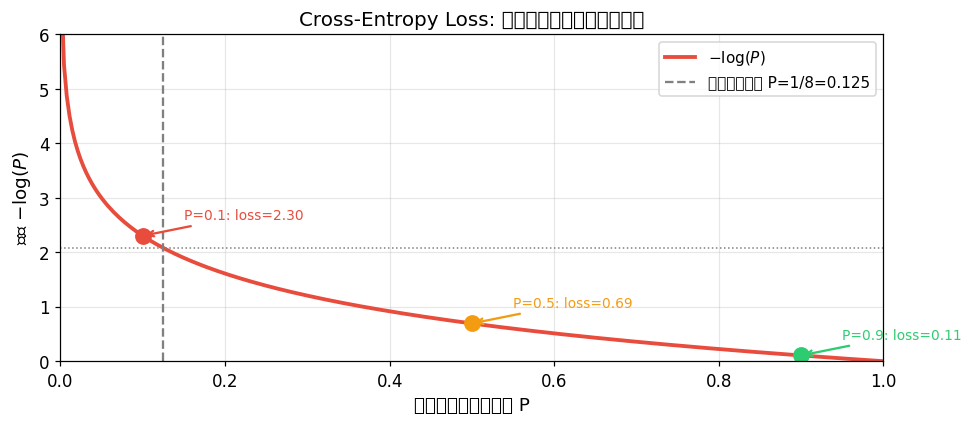

In [2]:
# -log(p) の可視化
p_vals = np.linspace(0.001, 1.0, 300)

fig, ax = plt.subplots(figsize=(9, 4))
ax.plot(p_vals, -np.log(p_vals), color='#e74c3c', lw=2.5, label='$-\\log(P)$')
ax.axvline(1/vocab_size, color='gray', ls='--', lw=1.5,
           label=f'ランダム予測 P=1/{vocab_size}={1/vocab_size:.3f}')
ax.axhline(np.log(vocab_size), color='gray', ls=':', lw=1)
ax.set_xlabel('正解トークンの確率 P', fontsize=12)
ax.set_ylabel('損失 $-\\log(P)$', fontsize=12)
ax.set_title('Cross-Entropy Loss: 確率が高いほど損失が低い', fontsize=13)
ax.set_xlim(0, 1); ax.set_ylim(0, 6)

for p_ex, color in [(0.9,'#2ecc71'), (0.5,'#f39c12'), (0.1,'#e74c3c')]:
    ax.plot(p_ex, -np.log(p_ex), 'o', color=color, markersize=10)
    ax.annotate(f'P={p_ex}: loss={-np.log(p_ex):.2f}',
                xy=(p_ex, -np.log(p_ex)),
                xytext=(p_ex+0.05, -np.log(p_ex)+0.3),
                fontsize=9, color=color,
                arrowprops=dict(arrowstyle='->', color=color, lw=1.5))

ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('docs/nb04_loss_curve.png', dpi=120, bbox_inches='tight')
plt.show()

In [3]:
# 実際に損失を計算
# 入力: [B,E,A,C] → 正解: [E,A,C,D]（各位置の次トークン）
input_ids  = [2, 5, 1, 3]
target_ids = [5, 1, 3, 4]   # E,A,C,D

logits_t, hidden = model_forward(input_ids)
probs = softmax(logits_t, axis=-1)

print(f"入力:  {[idx2word[i] for i in input_ids]}")
print(f"正解:  {[idx2word[i] for i in target_ids]}")
print()
print(f"{'位置':>4} {'正解':>5} {'正解の確率':>12} {'損失 -log(P)':>14}")
print("-" * 45)

losses = []
for i, tgt in enumerate(target_ids):
    p = probs[i, tgt]
    l = -np.log(p + 1e-9)
    losses.append(l)
    print(f"  {i:2d}    {idx2word[tgt]:>5}    {p:>12.6f}    {l:>14.6f}")

total_loss = np.mean(losses)
random_loss = np.log(vocab_size)
print("-" * 45)
print(f"平均損失: {total_loss:.6f}")
print(f"ランダム基準: {random_loss:.4f}  (log({vocab_size}))")
print(f"→ ランダムより {'良い ✓' if total_loss < random_loss else '悪い ✗'}")

入力:  ['B', 'E', 'A', 'C']
正解:  ['E', 'A', 'C', 'D']

  位置    正解        正解の確率     損失 -log(P)
---------------------------------------------
   0        E        0.128614          2.050939
   1        A        0.183606          1.694965
   2        C        0.078401          2.545915
   3        D        0.079749          2.528868
---------------------------------------------
平均損失: 2.205172
ランダム基準: 2.0794  (log(8))
→ ランダムより 悪い ✗


---
## 2. 勾配の直感：数値微分

**勾配**とは「パラメータを少し動かしたとき、損失がどれくらい変化するか」です：

$$\frac{\partial \mathcal{L}}{\partial w_{ij}} \approx \frac{\mathcal{L}(w_{ij}+\varepsilon) - \mathcal{L}(w_{ij}-\varepsilon)}{2\varepsilon}$$

- 勾配 > 0：$w_{ij}$ を増やすと損失が増える → **減らすべき**
- 勾配 < 0：$w_{ij}$ を増やすと損失が減る → **増やすべき**

この「勾配の逆方向に動く」操作が **勾配降下法** です。

In [4]:
def compute_loss_with_Wlm(W_lm_candidate):
    """W_lm を変えたときの損失（hidden は固定）"""
    lg = hidden @ W_lm_candidate
    pr = softmax(lg, axis=-1)
    return -np.mean(np.log(pr[np.arange(len(target_ids)), target_ids] + 1e-9))

eps = 1e-4
base_loss = compute_loss_with_Wlm(W_lm)

print("数値微分: W_lm のいくつかの要素に対する勾配")
print(f"基準損失 L = {base_loss:.6f}")
print()
print(f"{'要素':>12} {'W値':>10} {'L(W+ε)':>12} {'L(W-ε)':>12} {'数値勾配':>12}")
print("-" * 60)

numerical_grads = {}
for (i, j) in [(0,0), (1,2), (2,5), (3,7)]:
    W_plus  = W_lm.copy(); W_plus[i,j]  += eps
    W_minus = W_lm.copy(); W_minus[i,j] -= eps
    lp = compute_loss_with_Wlm(W_plus)
    lm = compute_loss_with_Wlm(W_minus)
    g  = (lp - lm) / (2*eps)
    numerical_grads[(i,j)] = g
    print(f"  W_lm[{i},{j}]:  {W_lm[i,j]:>10.4f} {lp:>12.6f} {lm:>12.6f} {g:>12.6f}")

数値微分: W_lm のいくつかの要素に対する勾配
基準損失 L = 2.205172

          要素         W値       L(W+ε)       L(W-ε)         数値勾配
------------------------------------------------------------
  W_lm[0,0]:     -0.0427     2.205175     2.205169     0.032168
  W_lm[1,2]:     -0.0501     2.205172     2.205172    -0.000937
  W_lm[2,5]:      0.0785     2.205155     2.205188    -0.166069
  W_lm[3,7]:      0.0158     2.205170     2.205174    -0.019522


---
## 3. 解析的な勾配（Softmax + Cross-Entropy）

Softmax と Cross-Entropy を組み合わせると、logits に対する勾配は驚くほどシンプルです：

$$\frac{\partial \mathcal{L}}{\partial \text{logits}_{i,j}} = \frac{1}{N}\left(P_{i,j} - \mathbf{1}[j = y_i]\right)$$

つまり **「予測確率 − 正解のワンホット」** を $N$ で割るだけです。

この美しい公式は連鎖律（Chain Rule）から導出されます：

$$\frac{\partial \mathcal{L}}{\partial \text{logits}} = \frac{\partial \mathcal{L}}{\partial \text{probs}} \cdot \frac{\partial \text{probs}}{\partial \text{logits}}$$

そして W_lm の勾配は：

$$\frac{\partial \mathcal{L}}{\partial W_{lm}} = \text{hidden}^\top \cdot \frac{\partial \mathcal{L}}{\partial \text{logits}} \in \mathbb{R}^{d_{\text{model}} \times |V|}$$

In [5]:
# 解析的勾配の計算
n = len(target_ids)
one_hot = np.zeros_like(probs)
one_hot[np.arange(n), target_ids] = 1.0

grad_logits = (probs - one_hot) / n   # (seq_len, vocab_size)
grad_W_lm   = hidden.T @ grad_logits  # (d_model, vocab_size)

print("probs（予測確率）:")
print(probs)
print()
print("one_hot（正解ラベル）:")
print(one_hot)
print()
print("∂L/∂logits = (probs - one_hot) / N:")
print(grad_logits)
print()
print(f"∂L/∂W_lm = hidden^T @ ∂L/∂logits: shape = {grad_W_lm.shape}")

probs（予測確率）:
[[0.1966 0.0405 0.1521 0.1585 0.1207 0.1286 0.136  0.0668]
 [0.1205 0.1836 0.143  0.163  0.077  0.0618 0.1438 0.1072]
 [0.0668 0.404  0.0737 0.0784 0.0642 0.06   0.072  0.1808]
 [0.0535 0.3764 0.08   0.0804 0.0797 0.0663 0.0929 0.1707]]

one_hot（正解ラベル）:
[[0. 0. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0. 0.]
 [0. 0. 0. 1. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0. 0.]]

∂L/∂logits = (probs - one_hot) / N:
[[ 0.0492  0.0101  0.038   0.0396  0.0302 -0.2178  0.034   0.0167]
 [ 0.0301 -0.2041  0.0357  0.0408  0.0193  0.0155  0.0359  0.0268]
 [ 0.0167  0.101   0.0184 -0.2304  0.0161  0.015   0.018   0.0452]
 [ 0.0134  0.0941  0.02    0.0201 -0.2301  0.0166  0.0232  0.0427]]

∂L/∂W_lm = hidden^T @ ∂L/∂logits: shape = (4, 8)


In [6]:
# 数値微分との比較
print("解析的勾配 vs 数値微分の比較:")
print(f"{'要素':>12} {'解析的勾配':>14} {'数値微分':>14} {'差（絶対値）':>14}")
print("-" * 56)
for (i, j), num_g in numerical_grads.items():
    ana_g = grad_W_lm[i, j]
    diff  = abs(ana_g - num_g)
    print(f"  W_lm[{i},{j}]:  {ana_g:>14.8f} {num_g:>14.8f} {diff:>14.2e}")
print()
print("→ 差は ε² オーダー（数値誤差のみ）。解析的勾配は正確 ✓")

解析的勾配 vs 数値微分の比較:
          要素          解析的勾配           数値微分         差（絶対値）
--------------------------------------------------------
  W_lm[0,0]:      0.03216780     0.03216780       2.58e-10
  W_lm[1,2]:     -0.00093693    -0.00093693       2.05e-10
  W_lm[2,5]:     -0.16606947    -0.16606947       1.37e-09
  W_lm[3,7]:     -0.01952164    -0.01952164       3.37e-10

→ 差は ε² オーダー（数値誤差のみ）。解析的勾配は正確 ✓


/tmp/ipykernel_2577/2727779557.py:18: UserWarning: Glyph 35486 (\N{CJK UNIFIED IDEOGRAPH-8A9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/2727779557.py:18: UserWarning: Glyph 24409 (\N{CJK UNIFIED IDEOGRAPH-5F59}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/2727779557.py:18: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/2727779557.py:18: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/2727779557.py:18: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/2727779557.py:18: UserWarning: Glyph 20104 (\N{CJK UNIFIED IDEOGRAPH-4E88}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/2727779557.py:18: UserWarning: Glyph 28204 (\N{CJK UNIFIED IDEOGRAPH-6E2C}

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20301 (\N{CJK UNIFIED IDEOGRAPH-4F4D}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32622 (\N{CJK UNIFIED IDEOGRAPH-7F6E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65288 (\N{FULLWIDTH LEFT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 65289 (\N{FULLWIDTH RIGHT PARENTHESIS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35486 (\N{CJK UNIFIED IDEOGRAPH-8A9E}) missing from font(s) DejaVu Sans.
  fig.canva

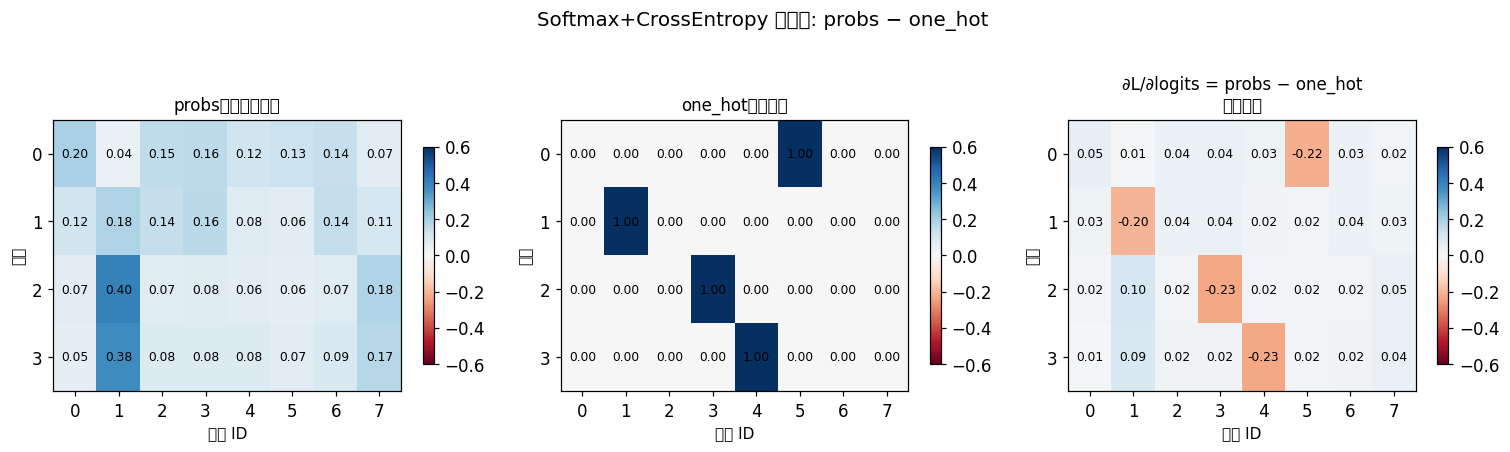

In [7]:
# 勾配の可視化
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

for ax, mat, title in zip(axes,
    [probs, one_hot, grad_logits],
    ['probs（予測確率）', 'one_hot（正解）', '∂L/∂logits = probs − one_hot\n（勾配）']):
    im = ax.imshow(mat, cmap='RdBu', aspect='auto', vmin=-0.6, vmax=0.6)
    ax.set_title(title, fontsize=11)
    ax.set_xlabel('語彙 ID', fontsize=10)
    ax.set_ylabel('位置', fontsize=10)
    ax.set_xticks(range(vocab_size)); ax.set_yticks(range(n))
    for i in range(n):
        for j in range(vocab_size):
            ax.text(j, i, f'{mat[i,j]:.2f}', ha='center', va='center', fontsize=8)
    plt.colorbar(im, ax=ax, shrink=0.8)

plt.suptitle('Softmax+CrossEntropy の勾配: probs − one_hot', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig('docs/nb04_gradient.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 4. 学習ループ（SGD）

**確率的勾配降下法（SGD）**：

$$W \leftarrow W - \eta \cdot \nabla_W \mathcal{L}$$

- $\eta$（学習率）：更新ステップの大きさ
- 小さすぎる：学習が遅い
- 大きすぎる：発散する

ここでは **W_lm だけを更新**します（簡略化のため。実際は全パラメータを更新）。

In [8]:
lr     = 0.05
n_step = 60

np.random.seed(99)
W_lm_train = np.random.randn(d_model, vocab_size) * 0.3

loss_history = []
correct_probs = []   # 各ステップでの正解トークンの平均確率

for step in range(n_step):
    # フォワードパス
    lg   = hidden @ W_lm_train
    pr   = softmax(lg, axis=-1)
    loss = -np.mean(np.log(pr[np.arange(n), target_ids] + 1e-9))
    loss_history.append(loss)
    correct_probs.append(pr[np.arange(n), target_ids].mean())

    # 勾配計算
    oh = np.zeros_like(pr); oh[np.arange(n), target_ids] = 1.0
    grad = hidden.T @ ((pr - oh) / n)

    # パラメータ更新
    W_lm_train -= lr * grad

print(f"Step  0: loss = {loss_history[0]:.4f}, 正解確率平均 = {correct_probs[0]:.4f}")
print(f"Step 30: loss = {loss_history[30]:.4f}, 正解確率平均 = {correct_probs[30]:.4f}")
print(f"Step 59: loss = {loss_history[-1]:.4f}, 正解確率平均 = {correct_probs[-1]:.4f}")

Step  0: loss = 2.2052, 正解確率平均 = 0.1176
Step 30: loss = 1.1559, 正解確率平均 = 0.3227
Step 59: loss = 0.7576, 正解確率平均 = 0.4779


/tmp/ipykernel_2577/2085359354.py:28: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/2085359354.py:28: UserWarning: Glyph 32722 (\N{CJK UNIFIED IDEOGRAPH-7FD2}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/2085359354.py:28: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/2085359354.py:28: UserWarning: Glyph 12486 (\N{KATAKANA LETTER TE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/2085359354.py:28: UserWarning: Glyph 12483 (\N{KATAKANA LETTER SMALL TU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/2085359354.py:28: UserWarning: Glyph 12503 (\N{KATAKANA LETTER PU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/2085359354.py:28: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) Dej

/tmp/ipykernel_2577/2085359354.py:28: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/2085359354.py:28: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/2085359354.py:28: UserWarning: Glyph 27491 (\N{CJK UNIFIED IDEOGRAPH-6B63}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/2085359354.py:28: UserWarning: Glyph 35299 (\N{CJK UNIFIED IDEOGRAPH-89E3}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/2085359354.py:28: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/2085359354.py:28: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/2085359354.py:28: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) mi

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 23398 (\N{CJK UNIFIED IDEOGRAPH-5B66}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32722 (\N{CJK UNIFIED IDEOGRAPH-7FD2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 26354 (\N{CJK UNIFIED IDEOGRAPH-66F2}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 32218 (\N{CJK UNIFIED IDEOGRAPH-7DDA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12473 (\N{KATAKANA LETTER SU}) missing from font(s) DejaVu Sans.
  fig.canvas.print_f

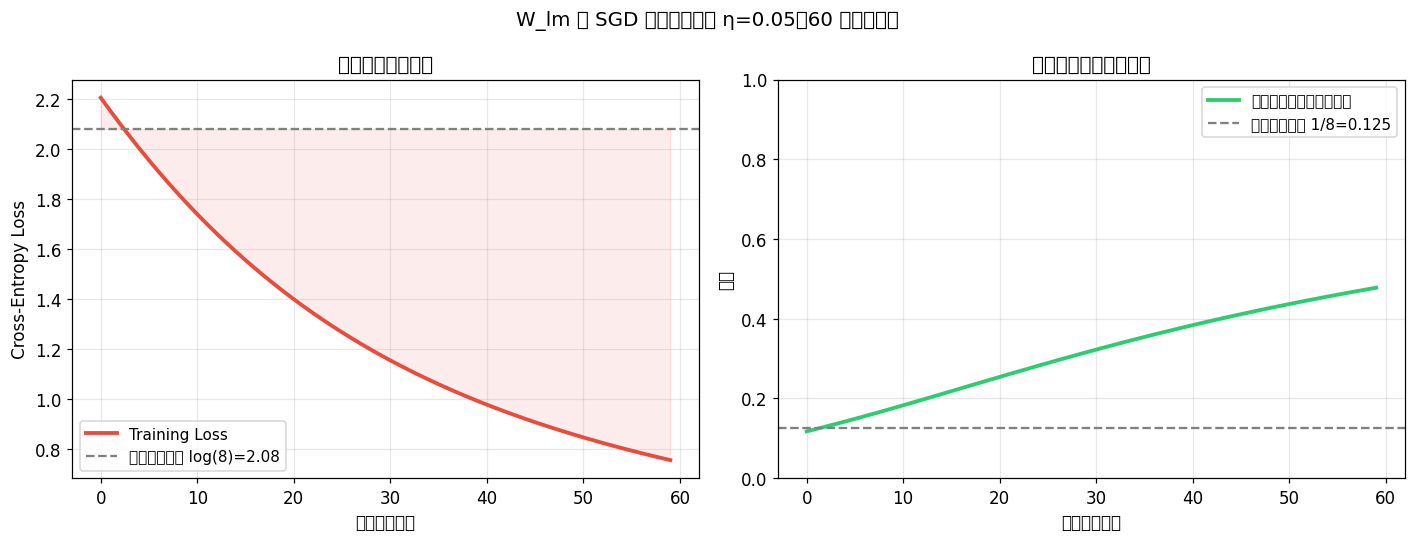

In [9]:
# 学習曲線の可視化
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# 損失曲線
axes[0].plot(loss_history, color='#e74c3c', lw=2.5, label='Training Loss')
axes[0].axhline(np.log(vocab_size), color='gray', ls='--', lw=1.5,
                label=f'ランダム基準 log({vocab_size})={np.log(vocab_size):.2f}')
axes[0].set_title('学習曲線（損失）', fontsize=13)
axes[0].set_xlabel('学習ステップ', fontsize=11)
axes[0].set_ylabel('Cross-Entropy Loss', fontsize=11)
axes[0].legend(fontsize=10)
axes[0].grid(True, alpha=0.3)
axes[0].fill_between(range(n_step), loss_history,
                      np.log(vocab_size), alpha=0.1, color='#e74c3c')

# 正解確率
axes[1].plot(correct_probs, color='#2ecc71', lw=2.5, label='正解トークンの平均確率')
axes[1].axhline(1/vocab_size, color='gray', ls='--', lw=1.5,
                label=f'ランダム基準 1/{vocab_size}={1/vocab_size:.3f}')
axes[1].set_title('正解トークンへの確率', fontsize=13)
axes[1].set_xlabel('学習ステップ', fontsize=11)
axes[1].set_ylabel('確率', fontsize=11)
axes[1].set_ylim(0, 1)
axes[1].legend(fontsize=10)
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'W_lm の SGD 学習（学習率 η={lr}、{n_step} ステップ）', fontsize=13)
plt.tight_layout()
plt.savefig('docs/nb04_training.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 5. 自己回帰的テキスト生成

GPT などの言語モデルは「次のトークンを 1 つずつ生成する」ループで動きます：

```
プロンプト [B, E] を入力
    ↓ フォワードパス
logits[-1]（最後の位置の予測）
    ↓ softmax + 選択
次トークン「A」を選ぶ
    ↓ 系列に追加
[B, E, A] を入力
    ↓ 繰り返す...
```

生成するたびにモデルに全系列を渡す（計算量は $O(L^2)$ で増加）。  
→ **KV Cache** という最適化で $O(L)$ に削減できます（発展トピック）。

In [10]:
def greedy_generate(prompt_ids, max_new_tokens=5, verbose=True):
    ids = list(prompt_ids)
    all_probs = []

    if verbose:
        print(f"プロンプト: {[idx2word[i] for i in ids]}")
        print()

    for step in range(max_new_tokens):
        lg, _ = model_forward(ids)
        p     = softmax(lg[-1])
        nid   = int(np.argmax(p))
        all_probs.append(p)

        if verbose:
            top3 = np.argsort(p)[::-1][:3]
            print(f"Step {step+1}: [{' '.join(idx2word[i] for i in ids)}]")
            print(f"  予測Top3: ", end="")
            for t in top3:
                print(f"{idx2word[t]}({p[t]:.3f})", end="  ")
            print(f"\n  → 選択: {idx2word[nid]}\n")

        ids.append(nid)
        if nid == 0: break

    return ids, all_probs

gen_ids, gen_probs = greedy_generate([2, 5], max_new_tokens=4)
print(f"生成結果: {' '.join(idx2word[i] for i in gen_ids)}")

プロンプト: ['B', 'E']

Step 1: [B E]
  予測Top3: A(0.184)  C(0.163)  F(0.144)  
  → 選択: A

Step 2: [B E A]
  予測Top3: A(0.404)  G(0.181)  C(0.078)  
  → 選択: A

Step 3: [B E A A]
  予測Top3: A(0.326)  G(0.200)  E(0.089)  
  → 選択: A

Step 4: [B E A A A]
  予測Top3: G(0.178)  E(0.173)  A(0.142)  
  → 選択: G

生成結果: B E A A A G


/tmp/ipykernel_2577/1007340504.py:25: UserWarning: Glyph 35486 (\N{CJK UNIFIED IDEOGRAPH-8A9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/1007340504.py:25: UserWarning: Glyph 24409 (\N{CJK UNIFIED IDEOGRAPH-5F59}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/1007340504.py:25: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/1007340504.py:25: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/1007340504.py:25: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/1007340504.py:25: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()


/tmp/ipykernel_2577/1007340504.py:25: UserWarning: Glyph 33258 (\N{CJK UNIFIED IDEOGRAPH-81EA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/1007340504.py:25: UserWarning: Glyph 24049 (\N{CJK UNIFIED IDEOGRAPH-5DF1}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/1007340504.py:25: UserWarning: Glyph 22238 (\N{CJK UNIFIED IDEOGRAPH-56DE}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/1007340504.py:25: UserWarning: Glyph 24112 (\N{CJK UNIFIED IDEOGRAPH-5E30}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/1007340504.py:25: UserWarning: Glyph 29983 (\N{CJK UNIFIED IDEOGRAPH-751F}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/1007340504.py:25: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/1007340504.py:25: UserWarning: Glyph 21508 (\N{CJK UNIFIED IDEOGRAPH-5404}

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20837 (\N{CJK UNIFIED IDEOGRAPH-5165}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 35486 (\N{CJK UNIFIED IDEOGRAPH-8A9E}) missing from font(s) DejaVu Sans.
  fig.canvas

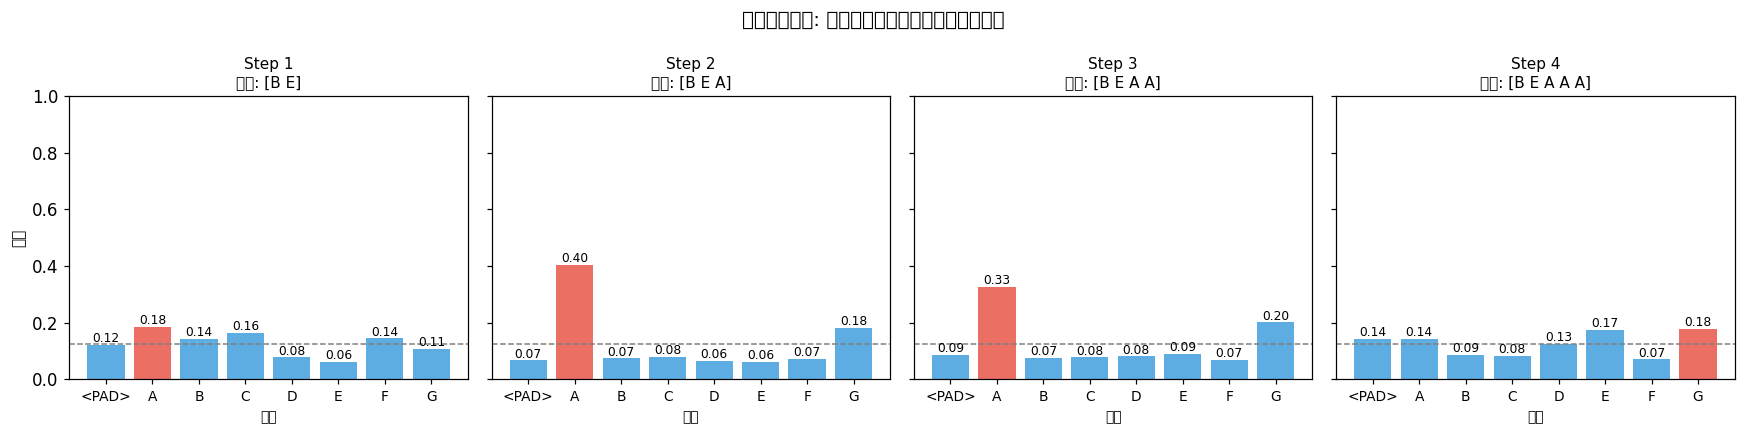

In [11]:
# 各生成ステップの確率分布を可視化
n_steps_vis = min(len(gen_probs), 4)
fig, axes   = plt.subplots(1, n_steps_vis, figsize=(4*n_steps_vis, 4), sharey=True)
if n_steps_vis == 1: axes = [axes]

prompt_vis = [2, 5]
ids_vis    = list(prompt_vis)

for step, (ax, p) in enumerate(zip(axes, gen_probs)):
    max_id = np.argmax(p)
    colors = ['#e74c3c' if j == max_id else '#3498db' for j in range(vocab_size)]
    ax.bar(range(vocab_size), p, color=colors, alpha=0.8)
    ax.set_title(f'Step {step+1}\n入力: [{" ".join(idx2word[i] for i in ids_vis)}]', fontsize=10)
    ax.set_xlabel('語彙', fontsize=9)
    if step == 0: ax.set_ylabel('確率', fontsize=10)
    ax.set_xticks(range(vocab_size))
    ax.set_xticklabels([idx2word[j] for j in range(vocab_size)], fontsize=9)
    ax.set_ylim(0, 1)
    ax.axhline(1/vocab_size, color='gray', ls='--', lw=1)
    for j, pj in enumerate(p):
        ax.text(j, pj+0.01, f'{pj:.2f}', ha='center', fontsize=8)
    ids_vis.append(int(np.argmax(p)))

plt.suptitle('自己回帰生成: 各ステップの次トークン確率分布', fontsize=13)
plt.tight_layout()
plt.savefig('docs/nb04_generation_steps.png', dpi=120, bbox_inches='tight')
plt.show()

---
## 6. サンプリング戦略の比較

### Temperature サンプリング

$$P_j = \text{softmax}\!\left(\frac{\text{logits}}{T}\right)_j$$

| T の値 | 分布の形 | 用途 |
|--------|---------|------|
| T → 0 | ほぼ Greedy | 決定論的・確実な回答 |
| T = 1 | 通常の softmax | 標準的な生成 |
| T > 1 | より平坦 | 創作・多様な出力 |

### Top-k サンプリング

確率上位 $k$ 個のトークンのみからサンプリングします。  
低確率の奇妙なトークンを排除しつつ、多様性を保ちます。

In [12]:
# Temperature の効果を数値で確認
example_logits = np.array([3.0, 1.5, 1.0, 0.5, -0.5, -1.0, -2.0, -2.5])

temps = [0.1, 0.5, 1.0, 2.0, 5.0]
print(f"logits = {example_logits}")
print()
print(f"{'T':>6} | {'max_prob':>10} | {'entropy':>10} | 分布")
print("-" * 70)
for T in temps:
    p    = softmax(example_logits / T)
    H    = -np.sum(p * np.log(p + 1e-9))
    bars = ''.join(['█'*int(pj*30) for pj in p])
    print(f"  {T:>4.1f} | {p.max():>10.4f} | {H:>10.4f} | {bars}")

logits = [ 3.   1.5  1.   0.5 -0.5 -1.  -2.  -2.5]

     T |   max_prob |    entropy | 分布
----------------------------------------------------------------------
   0.1 |     1.0000 |     0.0000 | █████████████████████████████
   0.5 |     0.9292 |     0.3206 | ████████████████████████████
   1.0 |     0.6667 |     1.1026 | ███████████████████████████
   2.0 |     0.3873 |     1.7371 | ██████████████████████████
   5.0 |     0.2144 |     2.0191 | ██████████████████████████


/tmp/ipykernel_2577/3969460174.py:20: UserWarning: Glyph 35486 (\N{CJK UNIFIED IDEOGRAPH-8A9E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/3969460174.py:20: UserWarning: Glyph 24409 (\N{CJK UNIFIED IDEOGRAPH-5F59}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/3969460174.py:20: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/3969460174.py:20: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/3969460174.py:20: UserWarning: Glyph 12456 (\N{KATAKANA LETTER E}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/3969460174.py:20: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/3969460174.py:20: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) Dej

/tmp/ipykernel_2577/3969460174.py:21: UserWarning: Glyph 12391 (\N{HIRAGANA LETTER DE}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb04_temperature.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2577/3969460174.py:21: UserWarning: Glyph 22810 (\N{CJK UNIFIED IDEOGRAPH-591A}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb04_temperature.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2577/3969460174.py:21: UserWarning: Glyph 27096 (\N{CJK UNIFIED IDEOGRAPH-69D8}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb04_temperature.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2577/3969460174.py:21: UserWarning: Glyph 24615 (\N{CJK UNIFIED IDEOGRAPH-6027}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb04_temperature.png', dpi=120, bbox_inches='tight')
/tmp/ipykernel_2577/3969460174.py:21: UserWarning: Glyph 12434 (\N{HIRAGANA LETTER WO}) missing from font(s) DejaVu Sans.
  plt.savefig('docs/nb04_temperature.png', dpi=120, bbox_inches='tight')
/

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 30906 (\N{CJK UNIFIED IDEOGRAPH-78BA}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 29575 (\N{CJK UNIFIED IDEOGRAPH-7387}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12456 (\N{KATAKANA LETTER E}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12531 (\N{KATAKANA LETTER N}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 12488 (\N{KATAKANA LETTER TO}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **

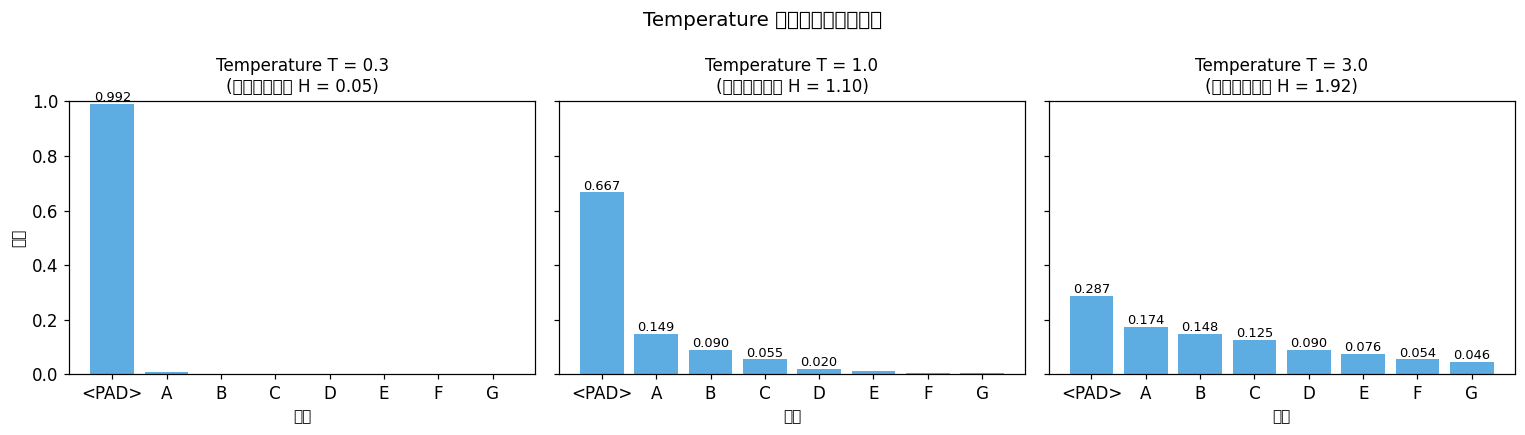

In [13]:
# Temperature の可視化
temps_vis = [0.3, 1.0, 3.0]
fig, axes = plt.subplots(1, 3, figsize=(14, 4), sharey=True)

for ax, T in zip(axes, temps_vis):
    p = softmax(example_logits / T)
    H = -np.sum(p * np.log(p + 1e-9))
    ax.bar(range(vocab_size), p, color='#3498db', alpha=0.8)
    ax.set_title(f'Temperature T = {T}\n(エントロピー H = {H:.2f})', fontsize=11)
    ax.set_xlabel('語彙', fontsize=10)
    if T == 0.3: ax.set_ylabel('確率', fontsize=10)
    ax.set_xticks(range(vocab_size))
    ax.set_xticklabels([idx2word[j] for j in range(vocab_size)])
    ax.set_ylim(0, 1)
    for j, pj in enumerate(p):
        if pj > 0.02:
            ax.text(j, pj+0.01, f'{pj:.3f}', ha='center', fontsize=8.5)

plt.suptitle('Temperature で多様性を制御する', fontsize=13)
plt.tight_layout()
plt.savefig('docs/nb04_temperature.png', dpi=120, bbox_inches='tight')
plt.show()

In [14]:
def temperature_sample(logits_1d, T=1.0, rng=None):
    if rng is None: rng = np.random.default_rng()
    p = softmax(logits_1d / T)
    return int(rng.choice(len(p), p=p))

def top_k_sample(logits_1d, k=3, T=1.0, rng=None):
    if rng is None: rng = np.random.default_rng()
    top_ids = np.argsort(logits_1d)[::-1][:k]
    p_top   = softmax(logits_1d[top_ids] / T)
    return int(top_ids[rng.choice(k, p=p_top)])

def sample_generate(prompt, strategy='greedy', T=1.0, k=3, max_new=5, seed=0):
    rng = np.random.default_rng(seed)
    ids = list(prompt)
    for _ in range(max_new):
        lg, _ = model_forward(ids)
        last  = lg[-1]
        if   strategy == 'greedy':      nid = int(np.argmax(softmax(last)))
        elif strategy == 'temperature': nid = temperature_sample(last, T, rng)
        elif strategy == 'top_k':       nid = top_k_sample(last, k, T, rng)
        ids.append(nid)
        if nid == 0: break
    return [idx2word[i] for i in ids]

prompt_ids = [2, 5]   # B, E
print(f"プロンプト: {[idx2word[i] for i in prompt_ids]}")
print()
print("【Greedy】")
print(" ", sample_generate(prompt_ids, strategy='greedy'))
print()
print("【Temperature=0.5（より確実）】")
for s in range(4): print(f"  試行{s+1}:", sample_generate(prompt_ids, strategy='temperature', T=0.5, seed=s))
print()
print("【Temperature=2.0（よりランダム）】")
for s in range(4): print(f"  試行{s+1}:", sample_generate(prompt_ids, strategy='temperature', T=2.0, seed=s))
print()
print("【Top-k=3, T=1.0】")
for s in range(4): print(f"  試行{s+1}:", sample_generate(prompt_ids, strategy='top_k', k=3, seed=s))

プロンプト: ['B', 'E']

【Greedy】
  ['B', 'E', 'A', 'A', 'A', 'G', 'D']

【Temperature=0.5（より確実）】
  試行1: ['B', 'E', 'C', 'A', 'A', '<PAD>']
  試行2: ['B', 'E', 'C', 'G', 'A', 'G', 'D']
  試行3: ['B', 'E', 'A', 'A', 'G', 'A', 'E']
  試行4: ['B', 'E', '<PAD>']

【Temperature=2.0（よりランダム）】
  試行1: ['B', 'E', 'D', 'A', '<PAD>']
  試行2: ['B', 'E', 'C', 'G', 'A', 'G', 'B']
  試行3: ['B', 'E', 'A', 'A', 'F', '<PAD>']
  試行4: ['B', 'E', '<PAD>']

【Top-k=3, T=1.0】
  試行1: ['B', 'E', 'C', 'A', 'A', 'E', '<PAD>']
  試行2: ['B', 'E', 'C', 'F', 'A', '<PAD>']
  試行3: ['B', 'E', 'A', 'A', 'G', 'D', 'E']
  試行4: ['B', 'E', 'A', 'A', 'G', 'E', 'C']


/tmp/ipykernel_2577/100539277.py:29: UserWarning: Glyph 12518 (\N{KATAKANA LETTER YU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/100539277.py:29: UserWarning: Glyph 12491 (\N{KATAKANA LETTER NI}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/100539277.py:29: UserWarning: Glyph 12540 (\N{KATAKANA-HIRAGANA PROLONGED SOUND MARK}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/100539277.py:29: UserWarning: Glyph 12463 (\N{KATAKANA LETTER KU}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/100539277.py:29: UserWarning: Glyph 20986 (\N{CJK UNIFIED IDEOGRAPH-51FA}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/100539277.py:29: UserWarning: Glyph 21147 (\N{CJK UNIFIED IDEOGRAPH-529B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2577/100539277.py:29: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font

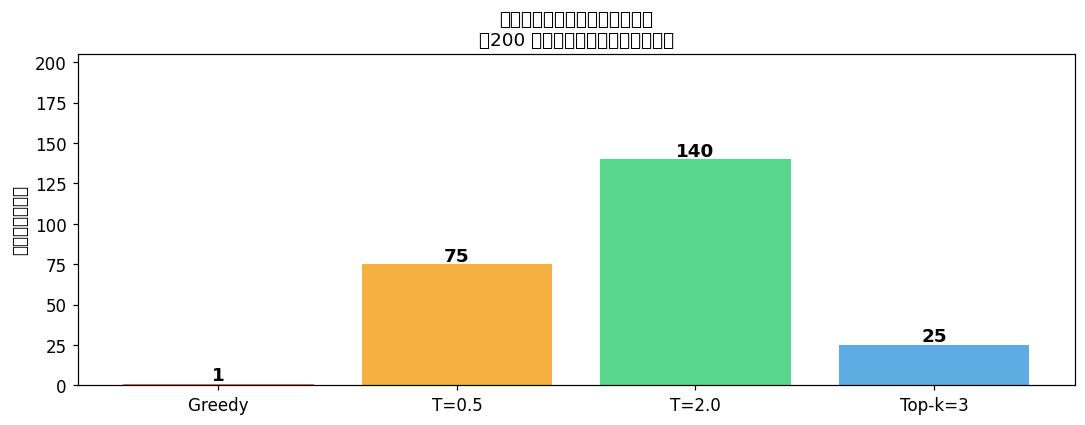

→ T が高いほど多様だが、低確率の奇妙なトークンも含まれやすい


In [15]:
# 各戦略を多数の試行で比較
n_trials = 200
results  = {'Greedy': [], 'T=0.5': [], 'T=2.0': [], 'Top-k=3': []}

for s in range(n_trials):
    for name, kwargs in [
        ('Greedy',   dict(strategy='greedy')),
        ('T=0.5',    dict(strategy='temperature', T=0.5)),
        ('T=2.0',    dict(strategy='temperature', T=2.0)),
        ('Top-k=3',  dict(strategy='top_k', k=3)),
    ]:
        seq = sample_generate(prompt_ids, max_new=3, seed=s, **kwargs)
        results[name].append(' '.join(seq))

# ユニーク出力数で多様性を測定
fig, ax = plt.subplots(figsize=(10, 4))
strategies = list(results.keys())
n_unique   = [len(set(results[s])) for s in strategies]
colors_bar = ['#e74c3c', '#f39c12', '#2ecc71', '#3498db']

bars = ax.bar(strategies, n_unique, color=colors_bar, alpha=0.8)
ax.set_title(f'サンプリング戦略の多様性比較\n（{n_trials} 回試行でのユニーク出力数）', fontsize=12)
ax.set_ylabel('ユニーク出力数', fontsize=11)
ax.set_ylim(0, n_trials + 5)
for bar, n in zip(bars, n_unique):
    ax.text(bar.get_x()+bar.get_width()/2, n+2, str(n),
            ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('docs/nb04_diversity.png', dpi=120, bbox_inches='tight')
plt.show()
print("→ T が高いほど多様だが、低確率の奇妙なトークンも含まれやすい")

---
## 全体まとめ：LLM の仕組みの全体像

```
テキスト
  │ [NB01] トークン化・埋め込み
  ↓
X = E[tokens] + PE      shape: (L, d_model)
  │ [NB02] Self-Attention
  ↓
Q,K,V = X @ W_{Q,K,V}
weights = softmax(QK^T/√dk + mask)
attn = weights @ V
  │ [NB03] Transformer ブロック × N
  ↓
X' = LN(X + MHA(X))
X_out = LN(X' + FFN(X'))
logits = X_out @ W_lm   shape: (L, |V|)
  │ [NB04] 学習・推論
  ↓
【学習時】 loss = -mean(log P(y))
          ∂L/∂logits = (probs - one_hot)/N
          W ← W - η * ∇W
【推論時】 next_token = sample(softmax(logits[-1]/T))
```

## 発展的なトピック

| トピック | 概要 | 参考 |
|---------|------|------|
| **Adam** | モメンタム + 適応的学習率。SGD より高速収束 | Kingma & Ba 2014 |
| **RoPE** | 相対位置エンコーディング。LLaMA で採用 | Su et al. 2021 |
| **Flash Attention** | メモリ効率的な Attention 実装 | Dao et al. 2022 |
| **KV Cache** | 推論高速化：過去の K/V を再計算しない | — |
| **Scaling Laws** | モデルサイズ・データ・計算量の関係 | Hoffmann et al. 2022 |
| **RLHF** | 人間フィードバックによる強化学習 | Ouyang et al. 2022 |

## 参考文献

1. Vaswani et al. (2017) "Attention Is All You Need"
2. Radford et al. (2018) "Improving Language Understanding by Generative Pre-Training" (GPT)
3. Brown et al. (2020) "Language Models are Few-Shot Learners" (GPT-3)
4. Andrej Karpathy's nanoGPT: https://github.com/karpathy/nanoGPT